In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# transformation for the Training (with Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Trasformation for Validation and Test (only resize and normalization, without distortion)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [2]:
dataset_path = 'dataset/Garbage classification'

# two view of the dataset, one for training and one for testing
full_train_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transforms)
full_test_dataset = datasets.ImageFolder(root=dataset_path, transform=test_transforms)

# let's verify that PyTorch is seeing all 6 classes
print(f"Classes found: {full_train_dataset.classes}")

# different dataset groups size
total_size = len(full_train_dataset)
train_size = int(0.7 * total_size)   # 70%
val_size = int(0.15 * total_size)    # 15%
test_size = total_size - train_size - val_size # 15%

print(f"Tot Images: {total_size}")
print(f"Training: {train_size} | Validation: {val_size} | Test: {test_size}")

# we need to create random index to mix photos before dividing them, so we use seed to make the action reproducible
torch.manual_seed(42)
indices = torch.randperm(total_size).tolist()

train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

# we assign the photos to the various groups. we pass "full_test_dataset" to val and test to not have the data augmentation
train_data = Subset(full_train_dataset, train_idx)
val_data = Subset(full_test_dataset, val_idx)
test_data = Subset(full_test_dataset, test_idx)

# create the DataLoader that loads the packets to the GPU
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Data ready")

Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Tot Images: 2527
Training: 1768 | Validation: 379 | Test: 380
Data ready


In [3]:
import os
import torch
import torch.nn as nn
import torchvision.models as models

# 1. check if GPU is active
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch type: {device}")

# Define the local filename for the original ResNet18 weights
base_weights_path = 'resnet18_base.pth'

# --- THE SMART OFFLINE CHECK ---
if os.path.exists(base_weights_path):
    print("Local ResNet18 base weights found! Loading completely offline...")
    # Initialize the empty architecture (weights=None stops the internet download)
    model = models.resnet18(weights=None)
    # Load our local weights into the empty shell
    model.load_state_dict(torch.load(base_weights_path))
else:
    print("Base weights not found locally. Downloading from the internet...")
    # Download the default weights
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Save a copy in our project folder so we never have to download it again!
    torch.save(model.state_dict(), base_weights_path)
    print("Base weights successfully saved locally for future use!")
# -------------------------------

# 2. Freeze all layers EXCEPT the final block (layer4) and the fully connected layer (fc)
for name, param in model.named_parameters():
    # If the parameter belongs to layer4 or the final classification head, let it learn!
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# 3. modify only the last layer (Fully Connected Layer)
num_ftrs = model.fc.in_features
class_number = 6 # we only have 6 classes (cardboard, glass, metal, paper, plastic, generic)

# create new final layer that is not freezed like the other ones, so it's the only one that will learn
model.fc = nn.Linear(num_ftrs, class_number)

# 4. move the model on the GPU/CPU
model = model.to(device)

print("ResNet18 model loaded and modified successfully")

Torch type: cpu
Local ResNet18 base weights found! Loading completely offline...
ResNet18 model loaded and modified successfully


In [4]:
import torch.optim as optim
from torch.optim import lr_scheduler

# for the Loss Function (Error) we use CrossEntropyLoss (standard for the multi-class classification)
criterion = nn.CrossEntropyLoss()

# for the Optimizer (that corrects the errors) we use Adam
# we only optimize the final layer parameters (model.fc) because the rest is freezed
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Decay LR by a factor of 0.5 every 5 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Loss e and Optimizer ready")

Loss e and Optimizer ready


In [5]:
import os
import torch

# name of the file where we save/load our AI weight
weights_path = 'transfer_resnet18_weights.pth'
skip_training = False  # default is to run the training loop

# checks if the file is already on your hard drive
if os.path.exists(weights_path):
    print(f"File '{weights_path}' found! Loading the pre-trained AI...")
    
    # Load the weights directly into our model
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    
    skip_training = True
    print("Model loaded successfully! You can skip the training loop and go straight to testing.")

else:
    print(f"File '{weights_path}' NOT found. Starting the training from scratch...")

File 'transfer_resnet18_weights.pth' found! Loading the pre-trained AI...
Model loaded successfully! You can skip the training loop and go straight to testing.


In [6]:
import copy
import time
import torch

# We only run the training if we didn't load the weights in the previous cell
if not skip_training:
    epochs = 30
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print("-" * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'train': # only step the scheduler after the training phase
                exp_lr_scheduler.step()

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - start_time
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # load the best weights back into the model
    model.load_state_dict(best_model_wts)
    
    # --- AUTOMATIC SAVING ---
    # Save the newly trained model to disk so we don't have to train it again tomorrow!
    torch.save(model.state_dict(), weights_path)
    print(f"Model successfully saved to '{weights_path}'!")
    
else:
    print("Training loop skipped because the model is already trained and loaded.")

Training loop skipped because the model is already trained and loaded.


Starting evaluation on the Test Set...

Classes detected: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

--- Classification Report ---
              precision    recall  f1-score   support

   cardboard       0.91      0.90      0.91        59
       glass       0.71      0.77      0.74        78
       metal       0.68      0.87      0.76        61
       paper       0.84      0.85      0.84        92
     plastic       0.86      0.65      0.74        66
       trash       0.75      0.50      0.60        24

    accuracy                           0.79       380
   macro avg       0.79      0.76      0.76       380
weighted avg       0.80      0.79      0.79       380



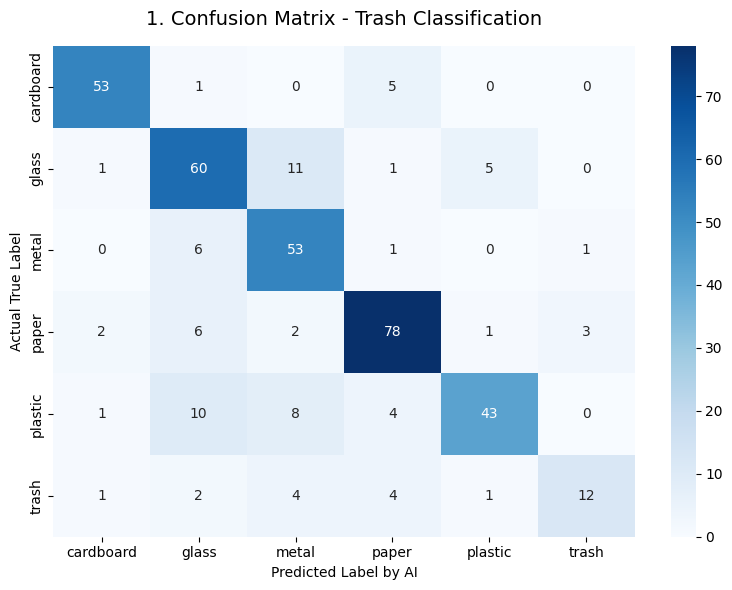

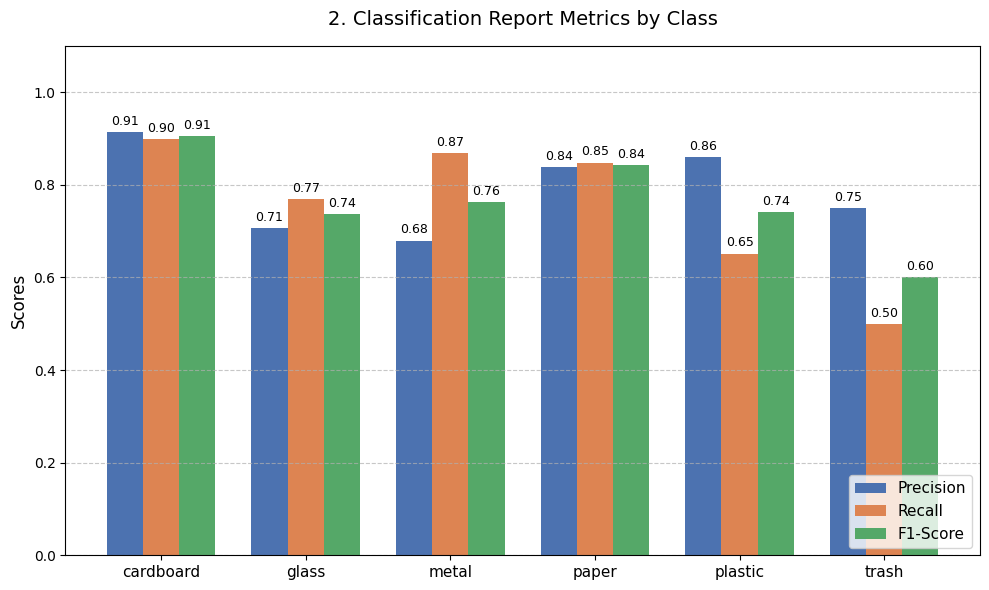

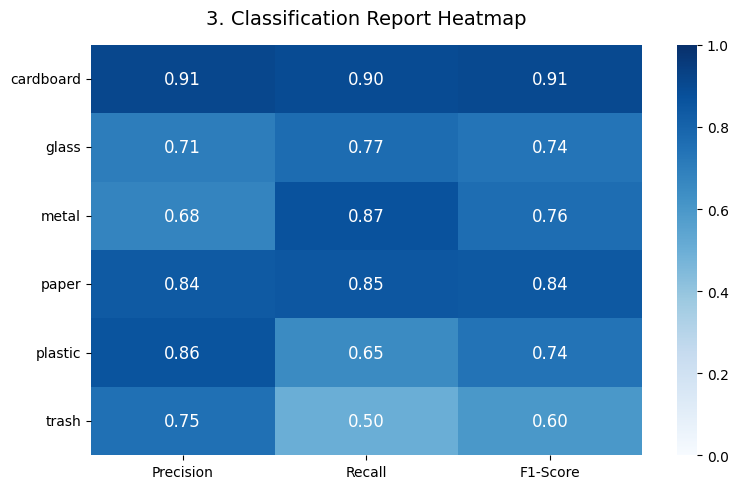

All evaluations completed and plots saved to disk!


In [7]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Set the model to evaluation mode
model.eval()

all_preds = []
all_labels = []

print("Starting evaluation on the Test Set...")

# 2. Iterate over the test data
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # append the current batch of predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Retrieve the actual class names
class_names = full_test_dataset.classes
print(f"\nClasses detected: {class_names}\n")

# --- TEXT REPORT ---
print("--- Classification Report ---")
# Print the standard text report
print(classification_report(all_labels, all_preds, target_names=class_names))

# Get the report as a dictionary to extract dynamic values for our plots
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

# Extract precision, recall, and f1-score lists dynamically
precision = [report_dict[cls]['precision'] for cls in class_names]
recall = [report_dict[cls]['recall'] for cls in class_names]
f1_score = [report_dict[cls]['f1-score'] for cls in class_names]

# ==========================================
# PLOT 1: CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('1. Confusion Matrix - Trash Classification', fontsize=14, pad=15)
plt.ylabel('Actual True Label')
plt.xlabel('Predicted Label by AI')
plt.tight_layout()
plt.savefig('transfer_1_confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# PLOT 2: GROUPED BAR CHART (METRICS)
# ==========================================
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4C72B0')
rects2 = ax.bar(x, recall, width, label='Recall', color='#DD8452')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#55A868')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('2. Classification Report Metrics by Class', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.savefig('transfer_2_metrics_barchart.png', dpi=300)
plt.show()

# ==========================================
# PLOT 3: METRICS HEATMAP
# ==========================================
data_metrics = np.array([precision, recall, f1_score]).T
df_metrics = pd.DataFrame(data_metrics, columns=['Precision', 'Recall', 'F1-Score'], index=class_names)

plt.figure(figsize=(8, 5))
sns.heatmap(df_metrics, annot=True, cmap='Blues', vmin=0, vmax=1, fmt='.2f', annot_kws={"size": 12})
plt.title('3. Classification Report Heatmap', fontsize=14, pad=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('transfer_3_metrics_heatmap.png', dpi=300)
plt.show()

print("All evaluations completed and plots saved to disk!")

Grad-CAM initialized. Picking 1 random test image per class (6 total)...


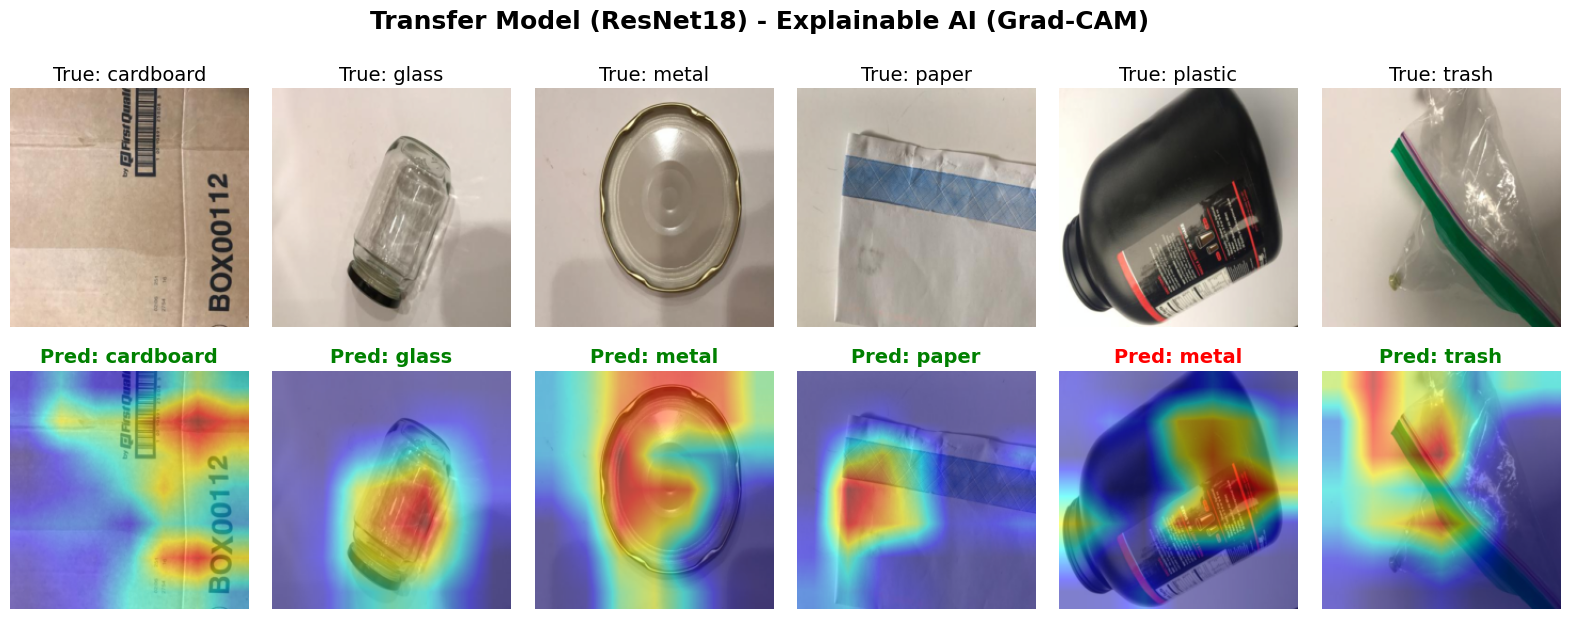

Heatmaps generated and saved successfully!


In [10]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Unfreeze the model parameters so Grad-CAM can backpropagate gradients
for param in model.parameters():
    param.requires_grad = True

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Setup Grad-CAM for the Transfer Model
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

print("Grad-CAM initialized. Picking 1 random test image per class (6 total)...")

model.eval()

# --- STRATIFIED RANDOMIZATION (1 image per class) ---
random_images = []
random_labels = []

# Iterate through each of the 6 classes to pick exactly one random image per class
for class_idx in range(len(class_names)):
    # Retrieve all indices in the test set belonging to the current class
    class_indices = [i for i, (_, label) in enumerate(test_data) if label == class_idx]
    # Pick exactly one random index for this class
    chosen_idx = random.choice(class_indices)
    
    img_tensor, label_idx = test_data[chosen_idx]
    random_images.append(img_tensor)
    random_labels.append(label_idx)

# Stack the selected images into a single batch tensor and move to device
inputs = torch.stack(random_images).to(device)
labels = torch.tensor(random_labels).to(device)
# ----------------------------------------------------

outputs = model(inputs)
_, preds = torch.max(outputs, 1)

# Create a 2x6 grid for the 6 classes, adjusting the width to fit perfectly
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i in range(6): # Loop through all 6 selected images
    input_tensor = inputs[i].unsqueeze(0)
    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i].item()]

    targets = [ClassifierOutputTarget(preds[i].item())]
    
    # Generate the heatmap
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    original_img = denormalize(inputs[i].cpu())
    visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)

    # Top Row: Original Image
    axes[0, i].imshow(original_img)
    axes[0, i].set_title(f"True: {true_label}", fontsize=14)
    axes[0, i].axis('off')

    # Bottom Row: Heatmap
    axes[1, i].imshow(visualization)
    color = 'green' if true_label == pred_label else 'red'
    axes[1, i].set_title(f"Pred: {pred_label}", color=color, fontsize=14, fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle("Transfer Model (ResNet18) - Explainable AI (Grad-CAM)", fontsize=18, fontweight='bold')

# Adjust spacing to avoid overlapping text
plt.subplots_adjust(hspace=0.1, top=0.88, wspace=0.1)
plt.savefig('transfer_4_gradcam.png', dpi=300)
plt.show()

print("Heatmaps generated and saved successfully!")

=== COMPARATIVE REPORT: BASELINE vs RESNET18 (on 380 test images) ===

    Class  Precision Baseline  Precision ResNet18  F1-Score Baseline  F1-Score ResNet18
Cardboard                0.88                0.91               0.87               0.91
    Glass                0.75                0.71               0.79               0.74
    Metal                0.70                0.68               0.72               0.76
    Paper                0.82                0.84               0.85               0.84
  Plastic                0.68                0.86               0.63               0.74
    Trash                0.82                0.75               0.68               0.60



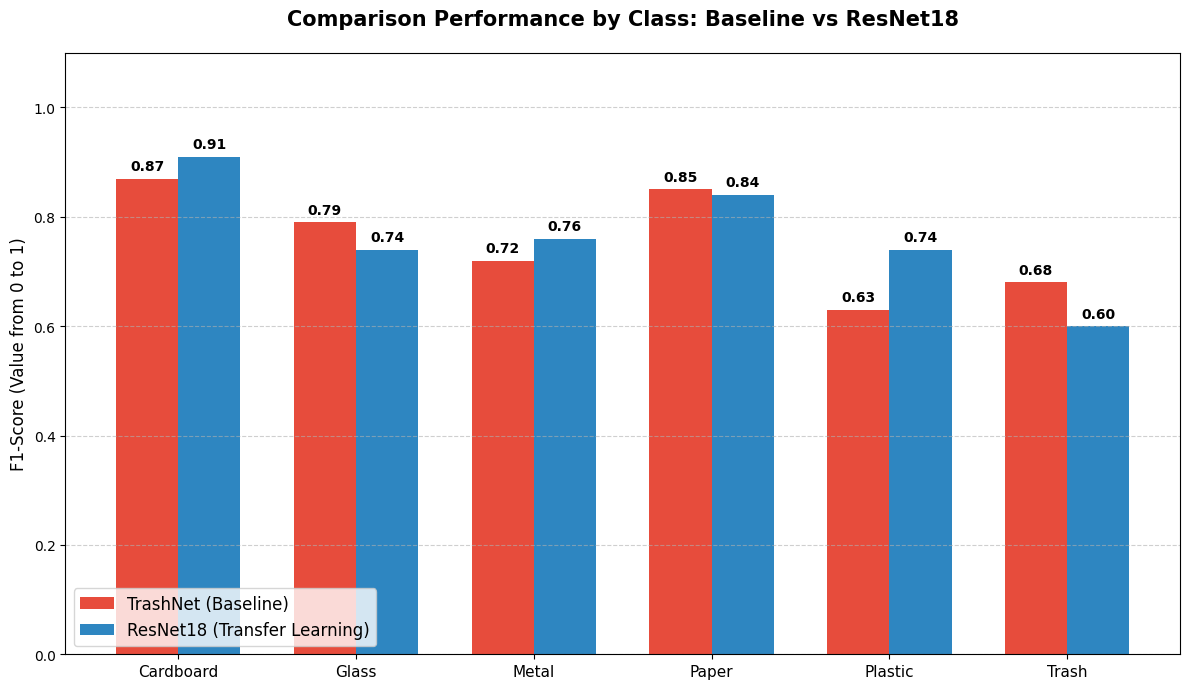

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Real data extracted from the tests on 380 images
classes = ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic', 'Trash']

# Data from Baseline (TrashNet Custom)
baseline_precision = [0.88, 0.75, 0.70, 0.82, 0.68, 0.82]
baseline_f1        = [0.87, 0.79, 0.72, 0.85, 0.63, 0.68]

# Data from Transfer Learning (ResNet18)
resnet_precision   = [0.91, 0.71, 0.68, 0.84, 0.86, 0.75]
resnet_f1          = [0.91, 0.74, 0.76, 0.84, 0.74, 0.60]

# --- COMPARATIVE TEXTUAL TABLE ---
print("=== COMPARATIVE REPORT: BASELINE vs RESNET18 (on 380 test images) ===\n")
data = {
    'Class': classes,
    'Precision Baseline': baseline_precision,
    'Precision ResNet18': resnet_precision,
    'F1-Score Baseline': baseline_f1,
    'F1-Score ResNet18': resnet_f1
}
df_compare = pd.DataFrame(data)
print(df_compare.to_string(index=False))
print("\n" + "="*70)

# --- GROUPED BAR CHART (F1-SCORE)
x = np.arange(len(classes))  # position of the labels
width = 0.35  # bars width

fig, ax = plt.subplots(figsize=(12, 7))

# Making of the two bars
rects1 = ax.bar(x - width/2, baseline_f1, width, label='TrashNet (Baseline)', color='#E74C3C') # Rosso
rects2 = ax.bar(x + width/2, resnet_f1, width, label='ResNet18 (Transfer Learning)', color='#2E86C1') # Blu

# Customization of the graph
ax.set_ylabel('F1-Score (Value from 0 to 1)', fontsize=12)
ax.set_title('Comparison Performance by Class: Baseline vs ResNet18', fontsize=15, pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.legend(loc='lower left', fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Function to add the numbers on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points for vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.savefig('model_comparison_f1.png', dpi=300)
plt.show()